In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import scipy.stats as s

In [2]:
data=pd.read_csv('employee.csv')

In [3]:
data.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
data = data.drop([
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
], axis=1)

In [7]:
data["Attrition"]=data["Attrition"].map({"Yes":1,"No":0})

In [8]:
data["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [9]:
data["OverTime"] = data["OverTime"].map({"Yes":1,"No":0})
data["Gender"] = data["Gender"].map({"Male":1,"Female":0})

In [10]:
data = pd.get_dummies(data, columns=[
    "Department",
    "JobRole",
    "MaritalStatus",
    "EducationField",
    "BusinessTravel"
])

In [11]:
data.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,MaritalStatus_Single,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely
0,41,1,1102,1,2,2,0,94,3,2,...,True,False,True,False,False,False,False,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,True,False,False,False,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,True,False,False,False,False,True,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,True,False,False,False,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,...,False,False,False,False,True,False,False,False,False,True


In [12]:
corr_matrix=data.corr()

In [13]:
corr_matrix

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,MaritalStatus_Single,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely
Age,1.000000,-0.159205,0.010661,-0.001686,0.208034,0.010146,-0.036311,0.024287,0.029820,0.509604,...,-0.119185,0.001696,0.016824,0.038162,-0.006354,-0.041466,-0.027604,-0.011215,-0.024743,0.028791
Attrition,-0.159205,1.000000,-0.056652,0.077924,-0.031373,-0.103369,0.029453,-0.006846,-0.130016,-0.169105,...,0.175419,0.036466,-0.032703,0.055781,-0.046999,-0.017898,0.069355,-0.074457,0.115143,-0.049538
DailyRate,0.010661,-0.056652,1.000000,-0.004985,-0.016806,0.018355,-0.011716,0.023381,0.046135,0.002966,...,-0.075835,-0.043144,0.004028,-0.064449,0.034202,-0.003893,0.030869,0.012096,-0.011776,0.002078
DistanceFromHome,-0.001686,0.077924,-0.004985,1.000000,0.021042,-0.016075,-0.001851,0.031131,0.008783,0.005303,...,-0.027445,-0.002624,-0.024499,0.039294,0.013486,-0.007969,-0.014802,0.023605,0.005081,-0.020116
Education,0.208034,-0.031373,-0.016806,0.021042,1.000000,-0.027128,-0.016547,0.016775,0.042438,0.101589,...,0.004168,0.026479,0.013184,0.072405,-0.072335,0.038043,-0.026742,0.004524,-0.008292,0.004126
EnvironmentSatisfaction,0.010146,-0.103369,0.018355,-0.016075,-0.027128,1.000000,0.000508,-0.049857,-0.008278,0.001212,...,0.009035,-0.006898,-0.024526,0.000479,-0.021299,0.064602,0.027713,0.003568,-0.012624,0.008496
Gender,-0.036311,0.029453,-0.011716,-0.001851,-0.016547,0.000508,1.000000,-0.000478,0.017960,-0.039403,...,-0.032752,0.028956,0.006770,-0.024143,-0.013146,0.022992,0.003886,0.050461,-0.022015,-0.014682
HourlyRate,0.024287,-0.006846,0.023381,0.031131,0.016775,-0.049857,-0.000478,1.000000,0.042861,-0.027853,...,-0.033436,-0.033670,0.038759,0.004452,-0.020418,-0.042163,0.011283,-0.016994,-0.018819,0.027541
JobInvolvement,0.029820,-0.130016,0.046135,0.008783,0.042438,-0.008278,0.017960,0.042861,1.000000,-0.012630,...,-0.045253,0.002079,0.003228,-0.018657,0.017103,-0.011895,-0.004519,-0.045779,0.004424,0.026714
JobLevel,0.509604,-0.169105,0.002966,0.005303,0.101589,0.001212,-0.039403,-0.027853,-0.012630,1.000000,...,-0.087072,0.010409,-0.008431,0.092698,-0.014114,-0.016724,-0.054707,-0.007295,-0.021557,0.023433


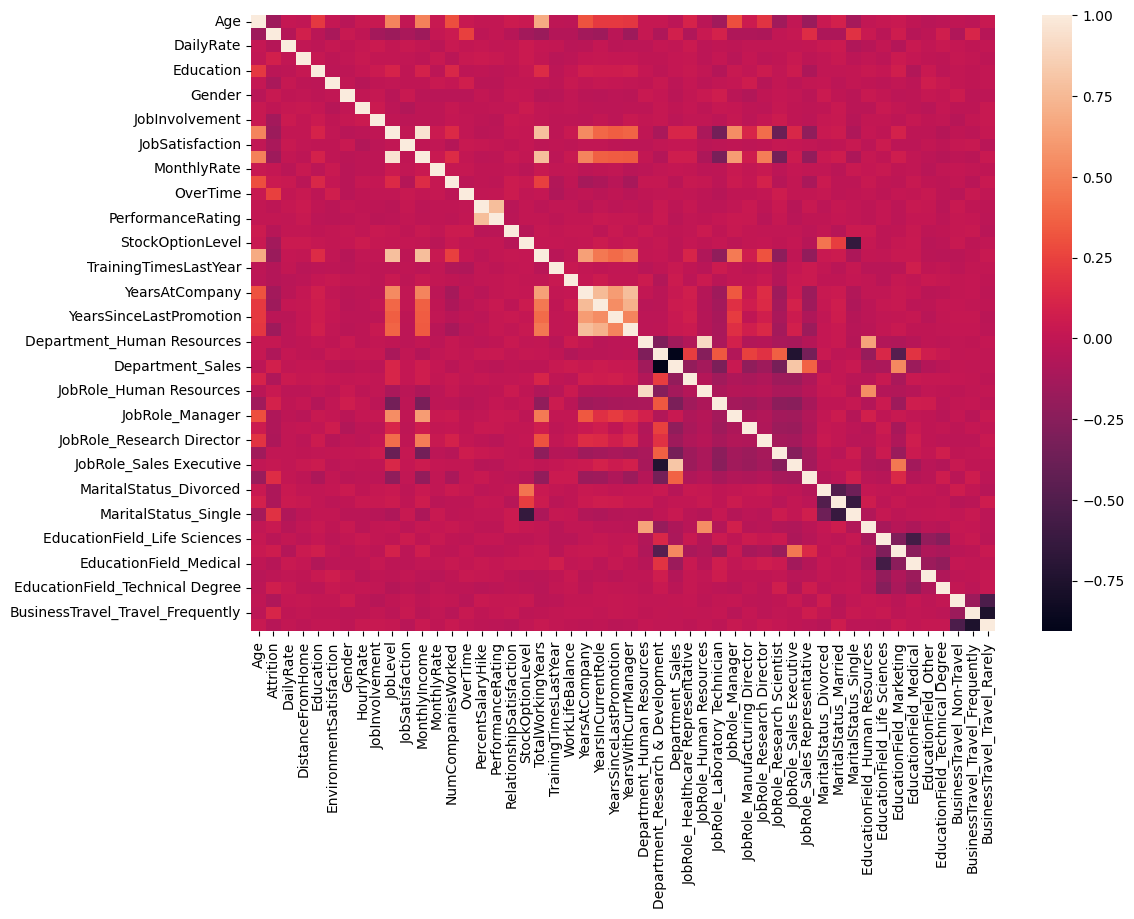

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix)
plt.show()

In [15]:
features = [
    "Age",
    "MonthlyIncome",
    "JobSatisfaction",
    "WorkLifeBalance",
    "DistanceFromHome",
    "OverTime",
    "YearsAtCompany",
    "NumCompaniesWorked",
    "PerformanceRating",
    "TotalWorkingYears"
]

In [16]:
X = data[features]
y = data["Attrition"]

In [17]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_scaled=sc.fit_transform(X)

In [18]:
X_scaled = pd.DataFrame(X_scaled, columns=features)

In [19]:
X_scaled

,Age,MonthlyIncome,JobSatisfaction,WorkLifeBalance,DistanceFromHome,OverTime,YearsAtCompany,NumCompaniesWorked,PerformanceRating,TotalWorkingYears
0,0.446350,-0.108350,1.153254,-2.493820,-1.010909,1.591746,-0.164613,2.125136,-0.426230,-0.421642
1,1.322365,-0.291719,-0.660853,0.338096,-0.147150,-0.628241,0.488508,-0.678049,2.346151,-0.164511
2,0.008343,-0.937654,0.246200,0.338096,-0.887515,1.591746,-1.144294,1.324226,-0.426230,-0.550208
3,-0.429664,-0.763634,0.246200,0.338096,-0.764121,1.591746,0.161947,-0.678049,-0.426230,-0.421642
4,-1.086676,-0.644858,-0.660853,0.338096,-0.887515,-0.628241,-0.817734,2.525591,-0.426230,-0.678774
...,...,...,...,...,...,...,...,...,...,...
1465,-0.101159,-0.835451,1.153254,0.338096,1.703764,-0.628241,-0.327893,0.523316,-0.426230,0.735447
1466,0.227347,0.741140,-1.567907,0.338096,-0.393938,-0.628241,-0.001333,0.523316,-0.426230,-0.293077
1467,-1.086676,-0.076690,-0.660853,0.338096,-0.640727,1.591746,-0.164613,-0.678049,2.346151,-0.678774
1468,1.322365,-0.236474,-0.660853,-1.077862,-0.887515,-0.628241,0.325228,-0.277594,-0.426230,0.735447


In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [21]:
processed_data = pd.concat([X_scaled, y], axis=1)

processed_data.to_csv("processed_attrition_data.csv", index=False)

In [22]:
processed_data

,Age,MonthlyIncome,JobSatisfaction,WorkLifeBalance,DistanceFromHome,OverTime,YearsAtCompany,NumCompaniesWorked,PerformanceRating,TotalWorkingYears,Attrition
0,0.446350,-0.108350,1.153254,-2.493820,-1.010909,1.591746,-0.164613,2.125136,-0.426230,-0.421642,1
1,1.322365,-0.291719,-0.660853,0.338096,-0.147150,-0.628241,0.488508,-0.678049,2.346151,-0.164511,0
2,0.008343,-0.937654,0.246200,0.338096,-0.887515,1.591746,-1.144294,1.324226,-0.426230,-0.550208,1
3,-0.429664,-0.763634,0.246200,0.338096,-0.764121,1.591746,0.161947,-0.678049,-0.426230,-0.421642,0
4,-1.086676,-0.644858,-0.660853,0.338096,-0.887515,-0.628241,-0.817734,2.525591,-0.426230,-0.678774,0
...,...,...,...,...,...,...,...,...,...,...,...
1465,-0.101159,-0.835451,1.153254,0.338096,1.703764,-0.628241,-0.327893,0.523316,-0.426230,0.735447,0
1466,0.227347,0.741140,-1.567907,0.338096,-0.393938,-0.628241,-0.001333,0.523316,-0.426230,-0.293077,0
1467,-1.086676,-0.076690,-0.660853,0.338096,-0.640727,1.591746,-0.164613,-0.678049,2.346151,-0.678774,0
1468,1.322365,-0.236474,-0.660853,-1.077862,-0.887515,-0.628241,0.325228,-0.277594,-0.426230,0.735447,0


In [23]:
X_train_tensor=torch.tensor(X_train.values,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.long)

Why randn for mu
- mu represents the mean vectors of the Gaussian distribution for each class.
- Initializing with torch.randn(...) gives small random values drawn from a standard normal distribution.
- This randomness ensures that different classes start with distinct mean values, preventing symmetry and helping the optimization process converge to meaningful solutions.
- If you initialized all means to zero, every class would look identical at the start, and the model might struggle to differentiate them.
🧩 Why zeros for log_sigma
- log_sigma represents the logarithm of the standard deviation (variance parameters).
- Initializing with torch.zeros(...) means that the starting standard deviation is e^0=1.
- This is a neutral, stable starting point: not too small (which could cause numerical instability) and not too large (which could make the distribution too flat).
- Using zeros avoids introducing unnecessary randomness into the scale of the distribution, keeping training stable.
⚖️ Intuition
- Means (mu): Random → diversity at the start.
- Variances (log_sigma): Neutral (1.0) → stability at the start.
Think of it like this: you want your model to explore different "centers" for each class (hence random means), but you don’t want it to be confused about how spread out those classes are initially (hence fixed variance).



Why zeros for log_sigma
- log_sigma represents the logarithm of the standard deviation (variance parameters).
- Initializing with torch.zeros(...) means that the starting standard deviation is e^0=1.
- This is a neutral, stable starting point: not too small (which could cause numerical instability) and not too large (which could make the distribution too flat).
- Using zeros avoids introducing unnecessary randomness into the scale of the distribution, keeping training stable


In [ ]:
class GaussianMLEstimatorNN(nn.Module):
    
    def __init__(self, num_features, num_classes):
        super().__init__()
        self.num_features = num_features
        self.num_classes = num_classes
        self.mu = nn.Parameter(torch.randn(num_classes, num_features))
        self.log_sigma = nn.Parameter(torch.zeros(num_classes, num_features))
        self.log_prior = nn.Parameter(torch.zeros(num_classes))
        
        
    def forward(self, x):
        sigma = torch.exp(self.log_sigma)
        x = x.unsqueeze(1)
        mu = self.mu.unsqueeze(0)
        sigma = sigma.unsqueeze(0)
        log_likelihood = -0.5 * (
            torch.log(2 * torch.pi * sigma**2)
            + ((x - mu)**2) / (sigma**2)
        )
        log_likelihood = log_likelihood.sum(dim=2)
        log_posterior = log_likelihood + self.log_prior
        return log_posterior

- x is your input data, likely shaped (batch_size, num_features).
- mu is the mean parameter, shaped (num_features, num_classes).
- sigma is the standard deviation, shaped (num_classes, num_features).
These shapes don’t line up naturally for elementwise operations. That’s why we use unsqueeze:
- x = x.unsqueeze(1)
- Changes shape from (batch_size, num_features) → (batch_size, 1, num_features).
- This adds a dimension for classes, so each input can be compared against all class means simultaneously.
- mu = self.mu.unsqueeze(0)
- Changes shape from (num_features, num_classes) → (1, num_features, num_classes).
- Now the batch dimension can broadcast across all samples.
- sigma = sigma.unsqueeze(0)
- Similarly, adds a batch dimension: (num_classes, num_features) → (1, num_classes, num_features).
⚖️ Why this matters
- After unsqueezing, PyTorch broadcasting rules allow subtraction (x - mu) and division by sigma to work across batch × class × feature dimensions.
- Without unsqueeze, you’d get shape mismatch errors.
🧩 And what about squeeze?
- squeeze is the opposite: it removes dimensions of size 1.
- Often used after likelihood computation to collapse unnecessary singleton dimensions, e.g. (batch_size, num_classes, 1) → (batch_size, num_classes).

👉 In short:
- unsqueeze = add dimensions so broadcasting works.
- squeeze = remove dimensions after computation to tidy up the result.


In [41]:
num_features = X_train.shape[1]
num_classes = 2

model = GaussianMLEstimatorNN(num_features, num_classes)

In [42]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

In [43]:
epochs = 500

for epoch in range(epochs):
    
    optimizer.zero_grad()
    
    outputs = model(X_train_tensor)
    
    loss = criterion(outputs, y_train_tensor)
    
    loss.backward()
    
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 1.962106466293335
Epoch 50, Loss: 0.5835265517234802
Epoch 100, Loss: 0.38263610005378723
Epoch 150, Loss: 0.3665868937969208
Epoch 200, Loss: 0.36078330874443054
Epoch 250, Loss: 0.3580251634120941
Epoch 300, Loss: 0.3565495014190674
Epoch 350, Loss: 0.3556753396987915
Epoch 400, Loss: 0.35510683059692383
Epoch 450, Loss: 0.3547043800354004


In [44]:
def predict(model, x):
    
    x = torch.tensor(x, dtype=torch.float32)
    
    with torch.no_grad():
        output = model(x)
        prediction = torch.argmax(output, dim=1)
        
    return prediction.numpy()

In [45]:
test_employee = [[
35,
5000,
3,
3,
10,
1,
5,
2,
3,
10
]]

prediction = predict(model, test_employee)

if prediction[0] == 1:
    print("Employee likely to leave")
else:
    print("Employee likely to stay")

Employee likely to leave


In [48]:
torch.save(model.state_dict(), "attrition_model.pth")

In [49]:
model = GaussianMLEstimatorNN(num_features, 2)
model.load_state_dict(torch.load("attrition_model.pth"))
model.eval()

GaussianMLEstimatorNN()